In [3]:
#  import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load & Explore dataset

path = r'C:/Users\osber\Desktop\AI MS\Walmart_Store_sales.csv'
df = pd.read_csv(path)

In [5]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,5/10/2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12/10/2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [6]:
df.head()


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,5/2/2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12/2/2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,5/3/2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


In [12]:
df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 719.0 KB


In [8]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [13]:
print(df.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [22]:
#Downcast integer columns them all in a loop

for col in df.columns:
    col_type = df[col].dtype
    if 'int' in str(col_type):
        df[col] = pd.to_numeric(df[col], downcast='integer')
    elif 'float' in str(col_type):
        df[col] = pd.to_numeric(df[col], downcast='float')    

In [ ]:
# Convert Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')


In [ ]:
# Create Month, Quarter, Year and Semester columns

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

df['Semester'] = np.where(df['Month']<=6,1,2)

# Which store has maximuimum sales?"""
 

In [28]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

In [29]:
print(store_sales)

Store
1     2.224028e+08
2     2.753824e+08
3     5.758674e+07
4     2.995440e+08
5     4.547569e+07
6     2.237561e+08
7     8.159828e+07
8     1.299512e+08
9     7.778922e+07
10    2.716177e+08
11    1.939628e+08
12    1.442872e+08
13    2.865177e+08
14    2.889999e+08
15    8.913368e+07
16    7.425243e+07
17    1.277821e+08
18    1.551147e+08
19    2.066349e+08
20    3.013978e+08
21    1.081179e+08
22    1.470756e+08
23    1.987506e+08
24    1.940160e+08
25    1.010612e+08
26    1.434164e+08
27    2.538559e+08
28    1.892637e+08
29    7.714155e+07
30    6.271689e+07
31    1.996139e+08
32    1.668192e+08
33    3.716022e+07
34    1.382498e+08
35    1.315207e+08
36    5.341221e+07
37    7.420274e+07
38    5.515963e+07
39    2.074455e+08
40    1.378703e+08
41    1.813419e+08
42    7.956575e+07
43    9.056544e+07
44    4.329309e+07
45    1.123953e+08
Name: Weekly_Sales, dtype: float64


In [31]:
max_store = store_sales.idxmax()

print("Store with Maximum Sales:",max_store)

Store with Maximum Sales: 20


In [32]:

print("Total Sales:",store_sales.max())

Total Sales: 301397792.46


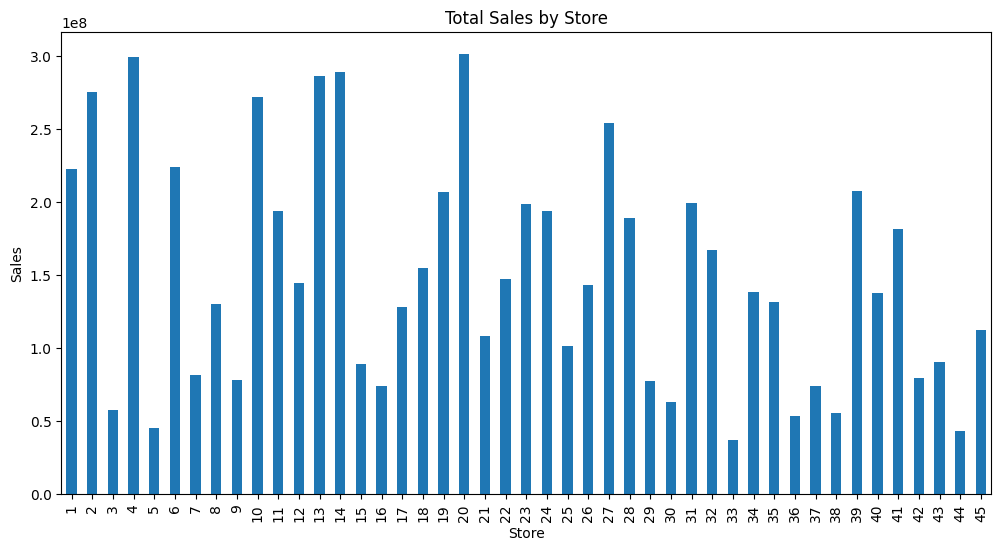

In [ ]:
# Plotting the total sales by store

plt.figure(figsize=(12,6))
store_sales.plot(kind='bar')
plt.title("Total Sales by Store")
plt.ylabel("Sales")
plt.show()

# Store with Maximum Standard Deviation

In [35]:
store_std = df.groupby('Store')['Weekly_Sales'].std()
print(store_std)

Store
1     155980.767761
2     237683.694682
3      46319.631557
4     266201.442297
5      37737.965745
6     212525.855862
7     112585.469220
8     106280.829881
9      69028.666585
10    302262.062504
11    165833.887863
12    139166.871880
13    265506.995776
14    317569.949476
15    120538.652043
16     85769.680133
17    112162.936087
18    176641.510839
19    191722.638730
20    275900.562742
21    128752.812853
22    161251.350631
23    249788.038068
24    167745.677567
25    112976.788600
26    110431.288141
27    239930.135688
28    181758.967539
29     99120.136596
30     22809.665590
31    125855.942933
32    138017.252087
33     24132.927322
34    104630.164676
35    211243.457791
36     60725.173579
37     21837.461190
38     42768.169450
39    217466.454833
40    119002.112858
41    187907.162766
42     50262.925530
43     40598.413260
44     24762.832015
45    130168.526635
Name: Weekly_Sales, dtype: float64


In [36]:
highest_std = store_std.idxmax()
print("Highest Std Store:",highest_std)

Highest Std Store: 14


# coefficient of mean to standard deviation. 

In [38]:
store_mean = df.groupby('Store')['Weekly_Sales'].mean()

cv = (store_std/store_mean)*100

cv = cv.sort_values(ascending=False)

print(cv)

Store
35    22.968111
7     19.730469
15    19.338399
29    18.374247
23    17.972115
21    17.029239
45    16.561273
16    16.518065
18    16.284550
36    16.257891
25    15.986040
10    15.913349
14    15.713674
22    15.678288
39    14.990779
41    14.817711
12    13.792532
28    13.732974
6     13.582286
27    13.515544
19    13.268012
13    13.251363
20    13.090269
4     12.708254
9     12.689547
17    12.552067
24    12.363738
40    12.342978
2     12.342388
11    12.226183
5     11.866844
32    11.831049
8     11.695283
3     11.502141
38    11.087545
26    11.011066
34    10.822524
1     10.029212
33     9.286835
42     9.033533
31     9.016105
44     8.179331
43     6.410363
30     5.200804
37     4.208412
Name: Weekly_Sales, dtype: float64


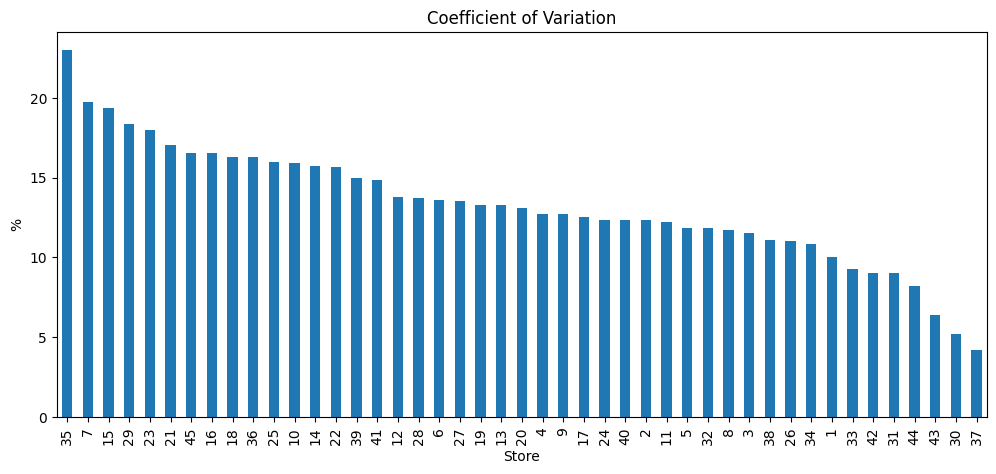

In [39]:
plt.figure(figsize=(12,5))
cv.plot(kind='bar')
plt.title("Coefficient of Variation")
plt.ylabel("%")
plt.show()

# Good Quarterly Growth Rate in Q3 2012

In [40]:
sales2012 = df[df['Year']==2012]

quarter_sales = sales2012.groupby(['Store','Quarter'])['Weekly_Sales'].sum().unstack()

quarter_sales

Quarter,1.0,2.0,3.0,4.0
Store,,,,
1,8353038.92,8517001.46,6655167.25,3243858.78
2,9728326.68,9890822.85,7753109.07,3899066.17
3,2211345.95,2253736.39,1631238.12,854362.04
4,11004571.33,11219453.75,8717485.82,4342861.50
5,1701768.40,1799361.30,1322818.21,668393.70
6,7631939.46,8278408.88,6700092.06,2977574.55
7,2987256.38,2788481.05,2760400.27,1009294.49
8,4733504.81,4754158.77,3696188.29,1903948.01
9,2873743.91,3022921.38,2217203.66,1165220.10


In [41]:
quarter_sales['Growth'] = ((quarter_sales[3]-quarter_sales[2])/quarter_sales[2])*100

quarter_sales.sort_values('Growth',ascending=False)

Quarter,1.0,2.0,3.0,4.0,Growth
Store,,,,,
7,2987256.38,2788481.05,2760400.27,1009294.49,-1.007028
16,2474350.89,2545407.51,2316939.66,963098.87,-8.975689
35,3831310.71,4240324.22,3724898.15,1739707.54,-12.155346
24,6444569.82,7060713.11,6059661.44,2833021.71,-14.177770
26,4975932.26,5247981.11,4474736.43,2140143.95,-14.734136
17,4659526.22,4788048.58,4029303.18,1872487.51,-15.846652
40,4815880.57,5209956.32,4347403.15,2051635.26,-16.555862
44,1596817.41,1651104.78,1373179.10,675186.57,-16.832710
41,6139489.80,6984565.34,5792598.00,2809705.92,-17.065734


# Best store 

In [42]:
print("Highest Growth Store")

print(quarter_sales['Growth'].idxmax())

print(quarter_sales['Growth'].max())

Highest Growth Store
7
-1.0070278225487599


# Holiday Sales vs Non-Holiday Mean

In [43]:
nonholiday_mean = df[df['Holiday_Flag']==0]['Weekly_Sales'].mean()

print(nonholiday_mean)

1041256.3802088555


# Holiday Mean

In [44]:
holiday_sales = df[df['Holiday_Flag']==1]

holiday_mean = holiday_sales.groupby('Date')['Weekly_Sales'].mean()

holiday_mean

Date
2010-02-12    1.074148e+06
2010-09-10    1.014098e+06
2011-02-11    1.051915e+06
2011-09-09    1.039183e+06
2012-02-10    1.111320e+06
2012-09-07    1.074001e+06
Name: Weekly_Sales, dtype: float64

# Higher than Non-Holiday Mean

In [45]:
holiday_mean[holiday_mean>nonholiday_mean]

Date
2010-02-12    1.074148e+06
2011-02-11    1.051915e+06
2012-02-10    1.111320e+06
2012-09-07    1.074001e+06
Name: Weekly_Sales, dtype: float64

# Monthly Sales

In [46]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()

monthly_sales

Month
1.0     8.773121e+07
2.0     2.876717e+08
3.0     2.787463e+08
4.0     2.406379e+08
5.0     1.894153e+08
6.0     2.923896e+08
7.0     2.435078e+08
8.0     2.373594e+08
9.0     2.332986e+08
10.0    2.282497e+08
11.0    1.890366e+08
12.0    2.105275e+08
Name: Weekly_Sales, dtype: float64

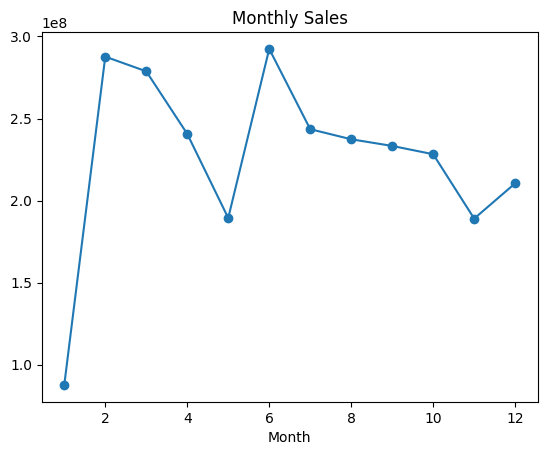

In [47]:
monthly_sales.plot(marker='o')

plt.title("Monthly Sales")

plt.show()